In [20]:
import pandas as pd
import matplotlib.pyplot as plt

**LOAD THE DATA**

In [22]:
df = pd.read_csv("/content/drive/MyDrive/compact.csv")
df.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN


In [32]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 543108 entries, 3 to 570605
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   country       543108 non-null  object        
 1   date          543108 non-null  datetime64[ns]
 2   total_cases   543108 non-null  float64       
 3   new_cases     543108 non-null  float64       
 4   total_deaths  543108 non-null  float64       
 5   population    543108 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 29.0+ MB


,0
country,0
date,0
total_cases,0
new_cases,0
total_deaths,0
population,0


**The dataset has covid data for different countries. Some values are missing so we need to clean it.**

**DATA CLEANING**

In [35]:
df['date'] = pd.to_datetime(df['date'])

# taking only required columns
df = df[['country','date','total_cases','new_cases','total_deaths','population']]

# removing missing values
df = df.dropna()

**ANALYSIS 1**

**INDIA CASES TREND**

We can see cases increased in waves. At some time it grows very fast.

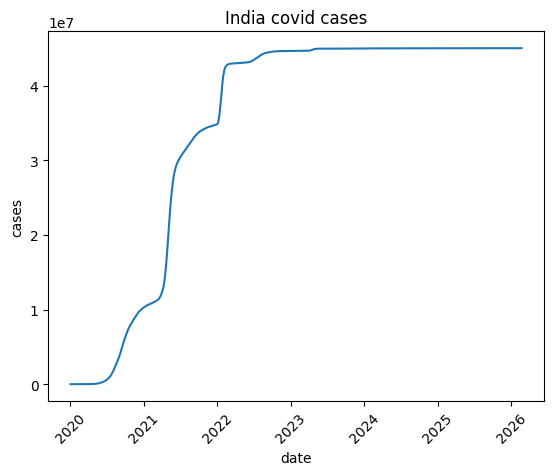

In [27]:
india = df[df['country'] == 'India']

plt.plot(india['date'], india['total_cases'])
plt.title("India covid cases")
plt.xlabel("date")
plt.ylabel("cases")
plt.xticks(rotation=45)
plt.show()

**ANALYSIS 2**

**TOP COUNTRIES**

Some countries have very high cases compared to others. Population might be a reason.

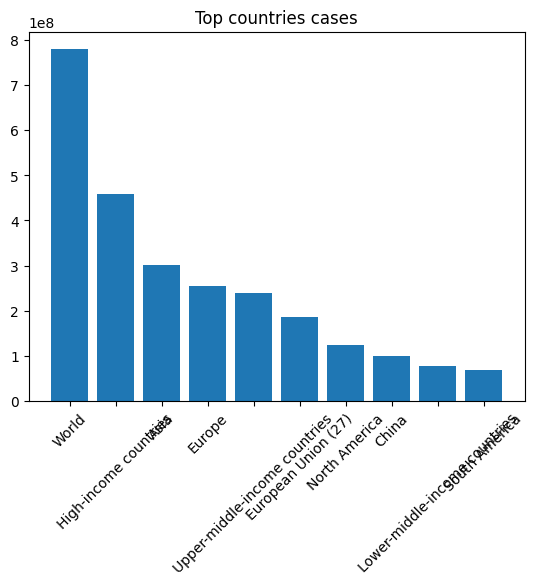

In [28]:
latest = df[df['date'] == df['date'].max()]

top10 = latest.sort_values('total_cases', ascending=False).head(10)

plt.bar(top10['country'], top10['total_cases'])
plt.xticks(rotation=45)
plt.title("Top countries cases")
plt.show()

**ANALYSIS 3**

**DEATH RATE**

Death rate is not same everywhere. It depends on healthcare and other factors.

/tmp/ipykernel_5666/2841289741.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest['death_rate'] = latest['total_deaths'] / latest['total_cases']


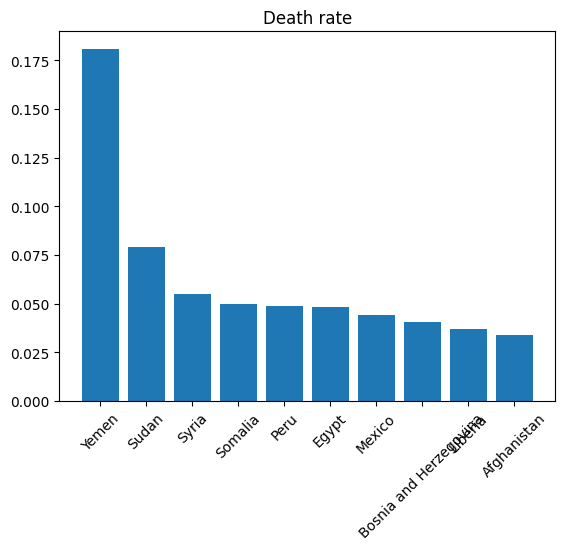

In [30]:
latest['death_rate'] = latest['total_deaths'] / latest['total_cases']

top = latest.sort_values('death_rate', ascending=False).head(10)

plt.bar(top['country'], top['death_rate'])
plt.xticks(rotation=45)
plt.title("Death rate")
plt.show()

**ANALYSIS 4**

**POPULATION VS CASES**

Bigger countries generally have more cases but not always.

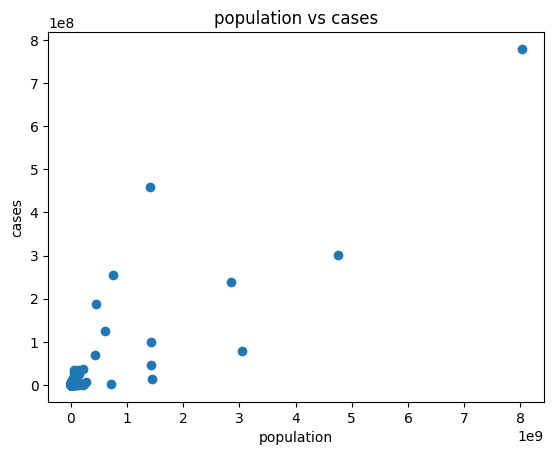

In [36]:
plt.scatter(latest['population'], latest['total_cases'])
plt.xlabel("population")
plt.ylabel("cases")
plt.title("population vs cases")
plt.show()

**CONCLUSION**

*   **The analysis shows that covid spread is not same in all countries. Some countries had higher cases and deaths. Factors like population and healthcare affect the spread. Graphs helped to understand trends clearly.**




